# **Technical Note - K-Nearest Neighbors**

##### KNN Binary Classification
1. Load and Prepare the Data

In [1]:
import pandas as pd
import numpy as np

data = pd.read_excel("loan_approval_data.xlsx")
data.head(5)

,participant_id,income,credit_score,owns_home,approve_loan
0,1,47467,608,no,no
1,2,56973,696,no,no
2,3,53816,663,no,no
3,4,68302,583,yes,no
4,5,56755,692,no,no


In [2]:
data['owns_home'] = pd.Categorical(data['owns_home'])
data['approve_loan'] = pd.Categorical(data['approve_loan'])

In [9]:
data['approve_loan'] = pd.Categorical(data['approve_loan'], categories=['yes','no'], ordered=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   participant_id  500 non-null    int64   
 1   income          500 non-null    int64   
 2   credit_score    500 non-null    int64   
 3   owns_home       500 non-null    category
 4   approve_loan    500 non-null    category
dtypes: category(2), int64(3)
memory usage: 13.1 KB


2. Inspect Raw Data

In [10]:
data.describe()

,participant_id,income,credit_score
count,500.000000,500.000000,500.000000
mean,250.500000,54435.898000,683.546000
std,144.481833,15073.811742,52.689356
min,1.000000,5188.000000,536.000000
25%,125.750000,45912.500000,646.000000
50%,250.500000,54099.000000,685.500000
75%,375.250000,64499.250000,719.250000
max,500.000000,104562.000000,835.000000


In [11]:
data['approve_loan'].value_counts()

approve_loan
no     349
yes    151
Name: count, dtype: int64

In [12]:
data['approve_loan'].value_counts(normalize=True)

approve_loan
no     0.698
yes    0.302
Name: proportion, dtype: float64

In [14]:
data.groupby('approve_loan')[['participant_id','income','credit_score']].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23236\2027370287.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('approve_loan')[['participant_id','income','credit_score']].mean()


,participant_id,income,credit_score
approve_loan,,,
yes,241.192053,64308.145695,708.019868
no,254.527221,50164.524355,672.957020


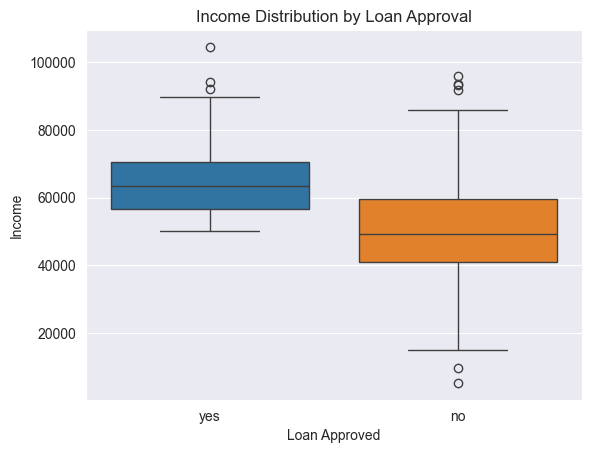

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
sns.boxplot(data=data, x='approve_loan', y='income', hue='approve_loan')
plt.title("Income Distribution by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Income")
plt.show()

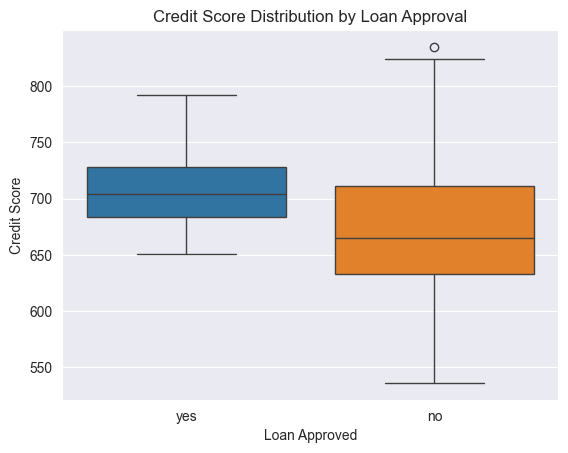

In [28]:
sns.set_style('darkgrid')
sns.boxplot(data=data, x='approve_loan', y='credit_score', hue='approve_loan')
plt.title("Credit Score Distribution by Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")
plt.show()

3. Stratified Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.3, stratify=data['approve_loan'], random_state=123)

print("Class Distribution in Full Dataset:\n", data['approve_loan'].value_counts(normalize=True).round(3))
print("Class Distribution in Data Train:\n", train_data['approve_loan'].value_counts(normalize=True).round(3))
print("Class Distribution in Data Test\n", test_data['approve_loan'].value_counts(normalize=True),round(3))

Class Distribution in Full Dataset:
 approve_loan
no     0.698
yes    0.302
Name: proportion, dtype: float64
Class Distribution in Data Train:
 approve_loan
no     0.697
yes    0.303
Name: proportion, dtype: float64
Class Distribution in Data Test
 approve_loan
no     0.7
yes    0.3
Name: proportion, dtype: float64 3


4. Standardize Numeric Features and Encode Categorical Binary Variable

- **Step 1: Preprocess train_data — Dummy Coding + Standardization**

In [ ]:
from scipy.stats import zscore

dummies = pd.get_dummies(train_data['owns_home'], prefix='owns_home')
train_data = pd.concat([train_data, dummies], axis=1)

train_data['income_scaled'] = pd.to_numeric(zscore(train_data['income']))
train_data['credit_scaled'] = pd.to_numeric(zscore(train_data['credit_score']))

- **Step 2: Save Scaling Parameters from Training Data**

We extract scalling parameters from the raw train_data['income'] subset. To standardize the test set using the trainning set's parameters - it helps us to avoid **data leakage**

In [43]:
income_center = train_data['income'].mean()
income_scale = train_data['income'].std()

credit_center = train_data['credit_score'].mean()
credit_scale = train_data['credit_score'].std()

- **Step 3: Apply the Same Transformation to test_data**

In [57]:
# Apply the same dummy column logic 
dummies1 = pd.get_dummies(test_data['owns_home'], prefix="owns_home")
test_data = pd.concat([test_data, dummies1], axis=1)

# Apply scaling using training parameters 
test_data['income_scaled'] = (test_data['income'] - income_center)/income_scale
test_data['credit_scaled'] = (test_data['credit_score'] - credit_center)/credit_scale

In [58]:
train_data.describe(include="all")

,participant_id,income,credit_score,owns_home,approve_loan,owns_home_no,owns_home_yes,income_scaled,credit_scaled
count,350.000000,350.000000,350.000000,350,350,350,350,3.500000e+02,3.500000e+02
unique,NaN,NaN,NaN,2,2,2,2,NaN,NaN
top,NaN,NaN,NaN,yes,no,False,True,NaN,NaN
freq,NaN,NaN,NaN,214,244,214,214,NaN,NaN
mean,254.731429,55072.665714,681.794286,NaN,NaN,NaN,NaN,-3.298948e-17,1.509903e-16
std,143.204392,15374.064349,52.567740,NaN,NaN,NaN,NaN,1.001432e+00,1.001432e+00
min,1.000000,5188.000000,555.000000,NaN,NaN,NaN,NaN,-3.249374e+00,-2.415470e+00
25%,134.500000,46081.750000,644.000000,NaN,NaN,NaN,NaN,-5.856478e-01,-7.199928e-01
50%,259.500000,55146.000000,683.000000,NaN,NaN,NaN,NaN,4.776829e-03,2.296923e-02
75%,375.750000,64877.000000,718.750000,NaN,NaN,NaN,NaN,6.386321e-01,7.040177e-01


In [59]:
test_data.describe(include="all")

,participant_id,income,credit_score,owns_home,approve_loan,owns_home_no,owns_home_yes,income_scaled,credit_scaled
count,150.000000,150.000000,150.000000,150,150,150,150,150.000000,150.000000
unique,NaN,NaN,NaN,2,2,2,2,NaN,NaN
top,NaN,NaN,NaN,yes,no,False,True,NaN,NaN
freq,NaN,NaN,NaN,91,105,91,91,NaN,NaN
mean,240.626667,52950.106667,687.633333,NaN,NaN,NaN,NaN,-0.138061,0.111077
std,147.430318,14288.339728,52.922181,NaN,NaN,NaN,NaN,0.929379,1.006743
min,2.000000,15098.000000,536.000000,NaN,NaN,NaN,NaN,-2.600136,-2.773455
25%,113.500000,45329.750000,651.750000,NaN,NaN,NaN,NaN,-0.633724,-0.571535
50%,220.000000,53393.500000,690.500000,NaN,NaN,NaN,NaN,-0.109221,0.165609
75%,365.750000,61658.750000,721.750000,NaN,NaN,NaN,NaN,0.428389,0.760081


5. Define Model Inputs (X and y)

In [60]:
# Define training predictors (X) and target (Y)
X_train = train_data[['income_scaled','credit_scaled','owns_home_no','owns_home_yes']]
y_train = train_data['approve_loan']

# Define test predictors and target
X_test = test_data[['income_scaled','credit_scaled','owns_home_no','owns_home_yes']]
y_test = test_data['approve_loan']

6. Train and Tune the KNN Classifier

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score

# Define the basic model
knn = KNeighborsClassifier()

# We are going to test from k=1 to 34. (In R, it is the closest to tuneLenght=15)
param_grid = {'n_neighbors': range(1,34,2)}

# Define the resampling method: 10-fold cross-validation
grid = GridSearchCV(
    estimator = knn,
    param_grid = param_grid,
    cv=10,  # Use k-fold cross-validation (Number of folds = 10)
    scoring = {'accuracy': 'accuracy',
                'kappa': make_scorer(cohen_kappa_score)},
    refit = 'accuracy',
    return_train_score = True
)

# Train the KNN model with cross-validation
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
results[['param_n_neighbors','mean_test_accuracy','mean_test_kappa']]

,param_n_neighbors,mean_test_accuracy,mean_test_kappa
0,1,0.974286,0.938513
1,3,0.962857,0.911233
2,5,0.971429,0.932558
3,7,0.982857,0.960507
4,9,0.980000,0.953415
5,11,0.980000,0.953407
6,13,0.980000,0.954037
7,15,0.982857,0.959885
8,17,0.982857,0.960565
9,19,0.974286,0.940846


In [ ]:
# Tthe best value for k according to cross-validation accuracy
print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 7}
0.9828571428571429


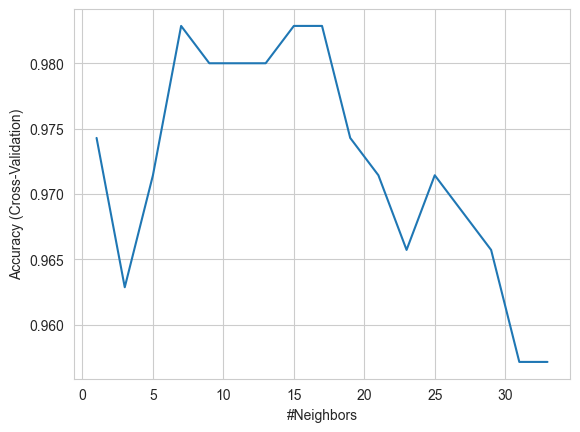

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

sns.lineplot(data=results, x='param_n_neighbors', y='mean_test_accuracy', markers="o", markersize=20)
plt.xlabel("#Neighbors")
plt.ylabel("Accuracy (Cross-Validation)")
plt.show()

7. Make Predictions on the Test Set

In [79]:
best_k = grid.best_params_['n_neighbors']

knn_final = KNeighborsClassifier(n_neighbors = best_k)
knn_final.fit(X_train, y_train)

pred_test = knn_final.predict(X_test)

8. Evaluate Model Performance

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, balanced_accuracy_score

# Confussion matrix
cm = confusion_matrix(y_test, pred_test, labels=['yes','no'])
print("Confussion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test, pred_test, target_names=['yes','no']))

Confussion Matrix:
 [[ 43   2]
 [  0 105]]
Classification Report:
               precision    recall  f1-score   support

         yes       0.98      1.00      0.99       105
          no       1.00      0.96      0.98        45

    accuracy                           0.99       150
   macro avg       0.99      0.98      0.98       150
weighted avg       0.99      0.99      0.99       150



In [84]:
print("Accuracy: ", accuracy_score(y_test, pred_test))
print("Kappa: ", cohen_kappa_score(y_test, pred_test))
print("Sensitivity: ", recall_score(y_test, pred_test, pos_label="yes"))
print("Specificity: ", recall_score(y_test, pred_test, pos_label="no"))
print("Positive Predictive Value (Precision)", precision_score(y_test, pred_test, pos_label="yes"))
print("Negative Predictive Value", precision_score(y_test, pred_test, pos_label="no"))
print("Balanced Accuracy", balanced_accuracy_score(y_test, pred_test))

Accuracy:  0.9866666666666667
Kappa:  0.9678456591639871
Sensitivity:  0.9555555555555556
Specificity:  1.0
Positive Predictive Value (Precision) 1.0
Negative Predictive Value 0.9813084112149533
Balanced Accuracy 0.9777777777777779


##### Cost-Sensitive Evaluation of the KNN Model

- **Step 1: Define the Cost Matrix**

In [85]:
# Define monetary consequences of each prediction outcome
cost_TP = -1000
cost_FP = 5000
cost_FN = 500
cost_TN = 0

- **Step 2: Extract Confusion Matrix Counts**

In [86]:
TP = 43
FP = 2
TN = 105
FN = 0

- **Step 3: Calculate Total Cost and Net Profit**

In [89]:
total_cost = (TP*cost_TP) + (FP*cost_FP) + (FN*cost_FN) + (TN*cost_TN)
net_profit = -total_cost
net_profit

33000

In [90]:
avg_profit_per_case = net_profit/(TP + FP + FN + TN)
avg_profit_per_case

220.0

⚠️ We can’t change k in KNN to minimize cost directly — but we can evaluate the cost consequences of our current model and compare it to other models (e.g. logistic regression, naive bayes).